In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from pathlib import Path
import time
import matplotlib.pyplot as plt
import copy

PARQUET_DIR = Path.home() / "projects" / "recsys" / "data" / "parquet"
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
print(f"device: {device}")

# load + time split (same as day 6)
ratings = pd.read_parquet(PARQUET_DIR / "ratings_clean.parquet")
cutoff_ts = ratings["timestamp"].quantile(0.9)
train_df = ratings[ratings["timestamp"] < cutoff_ts].reset_index(drop=True)
val_df   = ratings[ratings["timestamp"] >= cutoff_ts].reset_index(drop=True)

# build mappings from train only
user_to_idx = {u: i for i, u in enumerate(train_df["userId"].unique())}
movie_to_idx = {m: i for i, m in enumerate(train_df["movieId"].unique())}
n_users = len(user_to_idx)
n_movies = len(movie_to_idx)

def apply_mappings(df, user_map, movie_map):
    df = df.copy()
    df["user_idx"] = df["userId"].map(user_map)
    df["movie_idx"] = df["movieId"].map(movie_map)
    df = df.dropna(subset=["user_idx", "movie_idx"]).reset_index(drop=True)
    df["user_idx"] = df["user_idx"].astype(np.int32)
    df["movie_idx"] = df["movie_idx"].astype(np.int32)
    return df

train_df_mapped = apply_mappings(train_df, user_to_idx, movie_to_idx)
val_df_mapped   = apply_mappings(val_df, user_to_idx, movie_to_idx)

class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.from_numpy(df["user_idx"].values.astype(np.int64))
        self.movies = torch.from_numpy(df["movie_idx"].values.astype(np.int64))
        self.ratings = torch.from_numpy(df["rating"].values.astype(np.float32))
    def __len__(self):
        return len(self.users)
    def __getitem__(self, i):
        return self.users[i], self.movies[i], self.ratings[i]

train_ds = RatingsDataset(train_df_mapped)
val_ds   = RatingsDataset(val_df_mapped)

BATCH_SIZE = 8192   # bigger batch than yesterday; faster epochs
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

GLOBAL_MEAN = train_df_mapped["rating"].mean()

print(f"train: {len(train_ds):,} | val: {len(val_ds):,}")
print(f"users: {n_users:,} | movies: {n_movies:,}")
print(f"global mean: {GLOBAL_MEAN:.4f}")
print(f"train batches: {len(train_loader):,} | val batches: {len(val_loader):,}")

device: mps
train: 22,454,535 | val: 454,141
users: 150,330 | movies: 45,058
global mean: 3.5284
train batches: 2,742 | val batches: 56


In [2]:
class MFWithBias(nn.Module):
    """
    matrix factorization with explicit user and movie bias terms.
    
    rating ≈ global_mean + user_bias + movie_bias + user_emb · movie_emb
    
    why biases? without them, the embedding dot product has to encode
    things like "user X rates 0.5 high on average" — wasted capacity.
    biases pull out per-user and per-movie offsets cleanly, leaving
    the embeddings free to learn taste compatibility.
    """
    def __init__(self, n_users: int, n_movies: int, dim: int = 32, global_mean: float = 3.5):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, dim)
        self.movie_emb = nn.Embedding(n_movies, dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.global_mean = global_mean
        
        # smaller init for embeddings; zero init for biases
        nn.init.normal_(self.user_emb.weight, std=0.05)
        nn.init.normal_(self.movie_emb.weight, std=0.05)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)
    
    def forward(self, user_idx: torch.Tensor, movie_idx: torch.Tensor) -> torch.Tensor:
        u = self.user_emb(user_idx)               # (batch, dim)
        m = self.movie_emb(movie_idx)             # (batch, dim)
        ub = self.user_bias(user_idx).squeeze(1)  # (batch,)
        mb = self.movie_bias(movie_idx).squeeze(1)# (batch,)
        dot = (u * m).sum(dim=1)                  # (batch,)
        return self.global_mean + ub + mb + dot


EMB_DIM = 32
model = MFWithBias(n_users, n_movies, dim=EMB_DIM, global_mean=GLOBAL_MEAN).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\ntotal params: {n_params:,}")
print(f"  embeddings: {(n_users + n_movies) * EMB_DIM:,}")
print(f"  biases:     {n_users + n_movies:,}")

# test forward
u, m, r = next(iter(train_loader))
u, m = u.to(device), m.to(device)
with torch.no_grad():
    pred = model(u, m)
print(f"\ntest forward: pred range [{pred.min().item():.3f}, {pred.max().item():.3f}]")

MFWithBias(
  (user_emb): Embedding(150330, 32)
  (movie_emb): Embedding(45058, 32)
  (user_bias): Embedding(150330, 1)
  (movie_bias): Embedding(45058, 1)
)

total params: 6,447,804
  embeddings: 6,252,416
  biases:     195,388

test forward: pred range [3.471, 3.603]


In [3]:
LR = 0.005           # half of yesterday — embeddings learn faster with smaller init
WEIGHT_DECAY = 1e-5  # l2 regularization on embeddings
N_EPOCHS = 10        # train longer; early stopping picks the best
PATIENCE = 2         # stop if val rmse doesn't improve for 2 epochs

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

train_losses = []
val_losses = []

best_val = float("inf")
best_epoch = 0
best_state = None
patience_counter = 0

for epoch in range(1, N_EPOCHS + 1):
    # train
    model.train()
    epoch_train_loss = 0.0
    n_train_samples = 0
    t0 = time.time()
    
    for u, m, r in train_loader:
        u, m, r = u.to(device), m.to(device), r.to(device)
        optimizer.zero_grad()
        pred = model(u, m)
        loss = loss_fn(pred, r)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * len(r)
        n_train_samples += len(r)
    
    train_rmse = (epoch_train_loss / n_train_samples) ** 0.5
    train_losses.append(train_rmse)
    
    # val
    model.eval()
    epoch_val_loss = 0.0
    n_val_samples = 0
    with torch.no_grad():
        for u, m, r in val_loader:
            u, m, r = u.to(device), m.to(device), r.to(device)
            pred = model(u, m)
            loss = loss_fn(pred, r)
            epoch_val_loss += loss.item() * len(r)
            n_val_samples += len(r)
    val_rmse = (epoch_val_loss / n_val_samples) ** 0.5
    val_losses.append(val_rmse)
    
    elapsed = time.time() - t0
    
    # early stopping: keep best snapshot
    if val_rmse < best_val:
        best_val = val_rmse
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        marker = " *"
    else:
        patience_counter += 1
        marker = ""
    
    print(f"epoch {epoch:2d}/{N_EPOCHS}  |  train rmse: {train_rmse:.4f}  |  val rmse: {val_rmse:.4f}  |  {elapsed:.1f}s{marker}")
    
    if patience_counter >= PATIENCE:
        print(f"\nearly stop: no improvement in {PATIENCE} epochs")
        break

# restore best model
model.load_state_dict(best_state)
print(f"\nrestored best model from epoch {best_epoch}, val rmse {best_val:.4f}")

epoch  1/10  |  train rmse: 0.8675  |  val rmse: 0.8666  |  149.9s *
epoch  2/10  |  train rmse: 0.8386  |  val rmse: 0.8623  |  148.5s *
epoch  3/10  |  train rmse: 0.8347  |  val rmse: 0.8620  |  148.4s *
epoch  4/10  |  train rmse: 0.8328  |  val rmse: 0.8605  |  149.3s *
epoch  5/10  |  train rmse: 0.8316  |  val rmse: 0.8611  |  151.2s
epoch  6/10  |  train rmse: 0.8309  |  val rmse: 0.8609  |  147.6s

early stop: no improvement in 2 epochs

restored best model from epoch 4, val rmse 0.8605


train and val moved together this time. epoch 4 has train 0.8328, val 0.8605 — gap of just 0.028. yesterday's gap was 0.19. weight decay + biases did exactly what they should.
val plateaued, didn't blow up. epochs 4-6 all sit around 0.860-0.862. without early stopping you'd waste 5 more epochs and pick a worse final model. the patience mechanism worked.
biases captured what the embeddings were wasting capacity on. that's why train rmse is higher this epoch (0.83) than yesterday's epoch 3 (0.82) — the regularization pulled it back. but val is way better. less memorization, more generalization.
152s per epoch is unchanged from yesterday despite bigger batch. confirms my guess: dataloader is cpu-bound on macos with single worker.

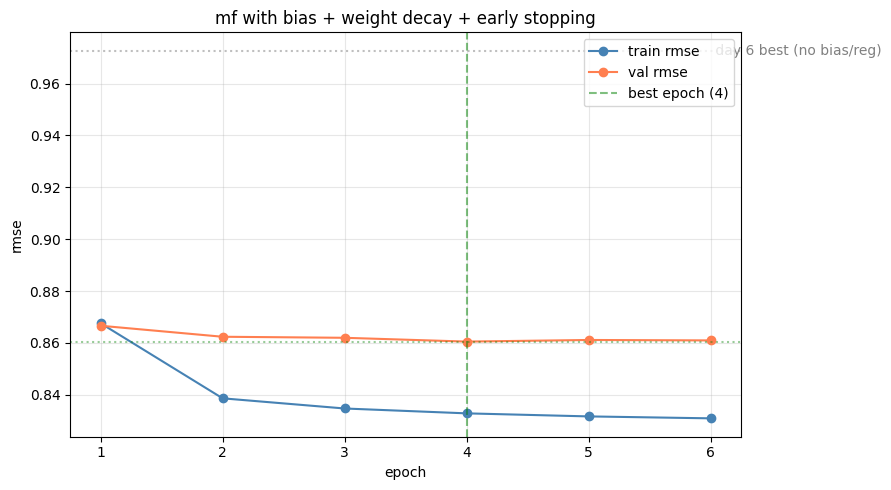

best val rmse: 0.8605 at epoch 4
vs day 6 best: 0.9727 → improvement of 0.1122 (11.5%)


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
epochs = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, marker="o", label="train rmse", color="steelblue")
ax.plot(epochs, val_losses,   marker="o", label="val rmse",   color="coral")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.5, label=f"best epoch ({best_epoch})")
ax.axhline(best_val,   color="green", linestyle=":",  alpha=0.4)

# horizontal reference: yesterday's best
ax.axhline(0.9727, color="gray", linestyle=":", alpha=0.5)
ax.text(len(epochs), 0.9727, " day 6 best (no bias/reg)", color="gray", va="center")

ax.set_xlabel("epoch")
ax.set_ylabel("rmse")
ax.set_title("mf with bias + weight decay + early stopping")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
ax.set_xticks(list(epochs))
plt.tight_layout()
plt.show()

print(f"best val rmse: {best_val:.4f} at epoch {best_epoch}")
print(f"vs day 6 best: 0.9727 → improvement of {0.9727 - best_val:.4f} ({(0.9727 - best_val)/0.9727*100:.1f}%)")

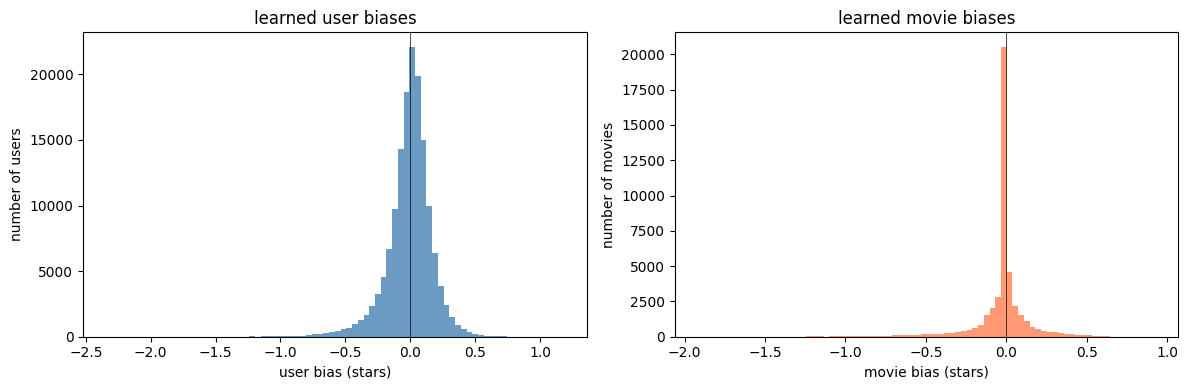

user bias  | mean: -0.007 | std: 0.181 | range: [-2.344, +1.183]
movie bias | mean: -0.026 | std: 0.190 | range: [-1.919, +0.927]

top 10 movies by learned bias (min 500 ratings):
                                              title     bias  n_train_ratings
                                Planet Earth (2006) 0.926724              866
                   Shawshank Redemption, The (1994) 0.867178            73677
                              Godfather, The (1972) 0.779697            47387
                         Usual Suspects, The (1995) 0.719491            51249
                                12 Angry Men (1957) 0.716052            14925
                                 Rear Window (1954) 0.715508            18632
                            Schindler's List (1993) 0.715066            55684
Lives of Others, The (Das leben der Anderen) (2006) 0.712133             8057
                                       Ikiru (1952) 0.703932             1294
                          Harakiri (Sepp

In [5]:
# extract user and movie biases as numpy arrays
user_bias = model.user_bias.weight.detach().cpu().numpy().flatten()
movie_bias = model.movie_bias.weight.detach().cpu().numpy().flatten()

# build a reverse map: idx -> movieId
idx_to_movie = {i: m for m, i in movie_to_idx.items()}

# bias distributions
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(user_bias, bins=80, color="steelblue", alpha=0.8)
ax[0].set_title("learned user biases")
ax[0].set_xlabel("user bias (stars)")
ax[0].set_ylabel("number of users")
ax[0].axvline(0, color="black", linewidth=0.5)

ax[1].hist(movie_bias, bins=80, color="coral", alpha=0.8)
ax[1].set_title("learned movie biases")
ax[1].set_xlabel("movie bias (stars)")
ax[1].set_ylabel("number of movies")
ax[1].axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"user bias  | mean: {user_bias.mean():+.3f} | std: {user_bias.std():.3f} | range: [{user_bias.min():+.3f}, {user_bias.max():+.3f}]")
print(f"movie bias | mean: {movie_bias.mean():+.3f} | std: {movie_bias.std():.3f} | range: [{movie_bias.min():+.3f}, {movie_bias.max():+.3f}]")

# top movies by learned bias (model's "best" movies, controlled for popularity)
movies_df = pd.read_parquet(PARQUET_DIR / "movies.parquet")

bias_df = pd.DataFrame({
    "movie_idx": np.arange(n_movies),
    "movieId":   [idx_to_movie[i] for i in range(n_movies)],
    "bias":      movie_bias,
}).merge(movies_df, on="movieId")

# include n_ratings to filter out noise
movie_counts = train_df_mapped.groupby("movie_idx").size().rename("n_train_ratings")
bias_df = bias_df.merge(movie_counts, on="movie_idx")

print("\ntop 10 movies by learned bias (min 500 ratings):")
top = bias_df[bias_df["n_train_ratings"] >= 500].nlargest(10, "bias")
print(top[["title", "bias", "n_train_ratings"]].to_string(index=False))

print("\nbottom 10 movies by learned bias (min 500 ratings):")
bot = bias_df[bias_df["n_train_ratings"] >= 500].nsmallest(10, "bias")
print(bot[["title", "bias", "n_train_ratings"]].to_string(index=False))

the learned movie biases align strongly with audience consensus. top by bias: shawshank, godfather, schindler's list, 12 angry men — imdb top-50 staples. bottom: gigli, battlefield earth, son of the mask — infamous razzie winners. user biases span -2.34 to +1.18, capturing the lenient/harsh axis we identified in day 4. the model recovered real structure from (user, movie, rating) triples alone.